# Canadian Grocery Price Analysis with Plotly


## Project Overview

Grocery prices vary significantly across products, regions and time. Understanding these differences usually requires more than simply looking at individual price values. This project uses Canadian retail price data to explore grocery price behaviour through multiple analytical perspectives and demonstrates how different **Plotly visualizations** can answer different business questions.

Rather than using one visualization for every problem, each chart is selected based on the question being answered.

**Business Problem → Analytical Question → Data Transformation → Visualization → Insight**

### Project Objective

The objective is to use data analysis and interactive visualization to understand:

- Where grocery prices are highest,
- Which products have experienced the largest increases,
- Which products show the greatest price instability,
- Which parts of a grocery basket are driving rising costs, and
- Whether unusual price movements can be identified for further investigation.

# Dataset Overview

*  It's from Statistics Canada, the government's official statistics agency.(https://www150.statcan.gc.ca/n1/en/catalogue/18100245)
*  It covers January 2017 to July 2026 - about nine and a half years of monthly data - across 106 everyday grocery items, and 11 regions: all 10 provinces, plus the national Canada-wide average.
*  Licence: published under the Open Government Licence – Canada, which means it's free to use, share, and publish, as long as Statistics Canada is credited as the source.




# Data Wrangling/EDA

The dataset is prepared so that prices can be compared consistently across products, locations and time through the following steps:

1. Inspect missing values
2. Remove unnecessary fields
3. Correct data types
4. Prepare price-related variables
5. Create time-based features for later analysis

Then, we explored the prepared dataset to understand its overall structure, distributions and patterns.This helped us to determine which transformations and Plotly visualizations are appropriate for the later analysis.

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


filepath ='sample_data/18100245.csv'
df = pd.read_csv(filepath, header=0)

print(df.head())

df.replace("?", np.nan, inplace = True)
print(df.head(5))

# Evaluating for Missing Data
missing_data = df.isnull()
print(missing_data.head(5))

for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")


df.drop(columns=["SYMBOL", "TERMINATED"], inplace=True)
print(df.head(5))

avg_value=df["VALUE"].astype(float).mean(axis=0)
df["VALUE"].replace(np.nan, avg_value, inplace=True)
print("Average VALUE:", avg_value)

# converting datatypes
df["REF_DATE"] = pd.to_datetime(df["REF_DATE"])
df["GEO"] = df["GEO"].astype('category')
df["DGUID"] = df["DGUID"].astype('object')
df["Products"] = df["Products"].astype('category')
df["UOM"] = df["UOM"].astype('object')
df["SCALAR_FACTOR"] = df["SCALAR_FACTOR"].astype('object')
df["VECTOR"] = df["VECTOR"].astype('object')


print(df.dtypes)
print(df.info())
df_norm = df.copy()

# keep only numeric columns (for normalization on value column)
df["VALUE_norm"] = (df["VALUE"] - df["VALUE"].min()) / (df["VALUE"].max() - df["VALUE"].min())

print(df.head(5))

# create 3 bins for VALUE
bins = np.linspace(df["VALUE"].min(), df["VALUE"].max(), 4)

group_names = ['Low', 'Medium', 'High']
df["VALUE_bin"] = pd.cut(df["VALUE"], bins, labels=group_names, include_lowest=True)

print(df[["VALUE", "VALUE_bin"]].head())

# indicator for data trend analysis
# 1. Price Change Indicator:

df = df.sort_values(["Products", "GEO", "REF_DATE"])

df["price_change"] = df.groupby(["Products", "GEO"])["VALUE"].diff()

df["price_pct_change"] = (
    df.groupby(["Products", "GEO"])["VALUE"]
      .pct_change()
)
# 2. Moving Average (trend):
df["MA_3"] = (
    df.groupby(["Products", "GEO"])["VALUE"]
      .transform(lambda x: x.rolling(3).mean())
)

df["MA_7"] = (
    df.groupby(["Products", "GEO"])["VALUE"]
      .transform(lambda x: x.rolling(7).mean())
)

# 3. Binary Up/Down Indicator:

df["price_up"] = (
    df.groupby(["Products", "GEO"])["VALUE"]
      .diff()
      .gt(0)
      .astype("Int64")
)

# 4. Category Indicator:
df["price_category"] = pd.cut(df["VALUE"], bins=3, labels=["Low", "Medium", "High"])

# 5. Date-based Indicators:
df["month"] = pd.to_datetime(df["REF_DATE"]).dt.month
df["year"] = pd.to_datetime(df["REF_DATE"]).dt.year
df["quarter"] = pd.to_datetime(df["REF_DATE"]).dt.quarter

print(df.head(5))
# Save the cleaned DataFrame to a new CSV file
df.to_csv('sample_data/18100245_cleaned.csv', index=False)

/tmp/ipykernel_1492/1767173485.py:9: DtypeWarning:

Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.



  REF_DATE     GEO           DGUID                             Products  \
0  2017-01  Canada  2021A000011124      Beef stewing cuts, per kilogram   
1  2017-01  Canada  2021A000011124    Beef striploin cuts, per kilogram   
2  2017-01  Canada  2021A000011124  Beef top sirloin cuts, per kilogram   
3  2017-01  Canada  2021A000011124          Beef rib cuts, per kilogram   
4  2017-01  Canada  2021A000011124            Ground beef, per kilogram   

       UOM  UOM_ID SCALAR_FACTOR  SCALAR_ID       VECTOR  COORDINATE  VALUE  \
0  Dollars      81         units          0  v1353834271       11.10  12.66   
1  Dollars      81         units          0  v1353834272       11.20  21.94   
2  Dollars      81         units          0  v1353834273       11.30  13.44   
3  Dollars      81         units          0  v1353834311       11.41  20.17   
4  Dollars      81         units          0  v1353834274       11.40   9.12   

  STATUS  SYMBOL  TERMINATED  DECIMALS  
0    NaN     NaN         NaN     

/tmp/ipykernel_1492/1767173485.py:30: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_1492/1767173485.py:65: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/1767173485.py:68: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=F

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140124 entries, 0 to 140123
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   REF_DATE       140124 non-null  datetime64[ns]
 1   GEO            140124 non-null  category      
 2   DGUID          140124 non-null  object        
 3   Products       140124 non-null  category      
 4   UOM            140124 non-null  object        
 5   UOM_ID         140124 non-null  int64         
 6   SCALAR_FACTOR  140124 non-null  object        
 7   SCALAR_ID      140124 non-null  int64         
 8   VECTOR         140124 non-null  object        
 9   COORDINATE     140124 non-null  float64       
 10  VALUE          140124 non-null  float64       
 11  STATUS         32 non-null      object        
 12  DECIMALS       140124 non-null  int64         
dtypes: category(2), datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 12.0+ MB
None
    REF_D

/tmp/ipykernel_1492/1767173485.py:73: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/1767173485.py:78: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/1767173485.py:85: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



       REF_DATE      GEO        DGUID            Products      UOM  UOM_ID  \
1092 2017-01-01  Alberta  2021A000248  Almonds, 200 grams  Dollars      81   
2301 2017-02-01  Alberta  2021A000248  Almonds, 200 grams  Dollars      81   
3510 2017-03-01  Alberta  2021A000248  Almonds, 200 grams  Dollars      81   
4719 2017-04-01  Alberta  2021A000248  Almonds, 200 grams  Dollars      81   
5928 2017-05-01  Alberta  2021A000248  Almonds, 200 grams  Dollars      81   

     SCALAR_FACTOR  SCALAR_ID       VECTOR  COORDINATE  ...  VALUE_bin  \
1092         units          0  v1458870202       9.107  ...        Low   
2301         units          0  v1458870202       9.107  ...        Low   
3510         units          0  v1458870202       9.107  ...        Low   
4719         units          0  v1458870202       9.107  ...        Low   
5928         units          0  v1458870202       9.107  ...        Low   

     price_change  price_pct_change      MA_3 MA_7  price_up  price_category  \
1092  

In [ ]:
#Creating Food Category

def assign_food_category(product):

    p = product.lower()

    # Meat & Poultry
    if any(x in p for x in [
        "beef", "chicken", "pork", "bacon",
        "wieners"
    ]):
        return "Meat & Poultry"

    # Seafood
    elif any(x in p for x in [
        "salmon", "tuna", "shrimp"
    ]):
        return "Seafood"

    # Dairy & Eggs
    elif any(x in p for x in [
        "milk", "cheese", "butter", "cream",
        "yogurt", "eggs"
    ]) and "nut milk" not in p and "soy milk" not in p:
        return "Dairy & Eggs"

    # Fruits
    elif any(x in p for x in [
        "apple", "banana", "avocado", "cantaloupe",
        "grape", "lemon", "lime", "orange",
        "pear", "strawberr"
    ]) and "juice" not in p and "canned" not in p:
        return "Fruits"

    # Vegetables
    elif any(x in p for x in [
        "broccoli", "cabbage", "carrot", "celery",
        "cucumber", "lettuce", "mushroom", "onion",
        "pepper", "potato", "spinach", "squash",
        "tomato", "salad greens", "green beans",
        "mixed vegetables", "peas", "corn"
    ]) and "canned" not in p:
        return "Vegetables"

    # Grains & Bakery
    elif any(x in p for x in [
        "rice", "pasta", "cereal", "flour",
        "bread", "flatbread", "pita",
        "cracker"
    ]) and "pasta sauce" not in p:
        return "Grains & Bakery"

    # Pantry & Packaged Foods
    elif any(x in p for x in [
        "canned", "soup", "pizza", "french fried",
        "ketchup", "mayonnaise", "pasta sauce",
        "salad dressing", "salsa", "sugar",
        "cookies", "sweet biscuits"
    ]):
        return "Pantry & Packaged Foods"

    # Plant Proteins & Nuts
    elif any(x in p for x in [
        "almonds", "lentils", "legumes",
        "hummus", "peanut", "sunflower",
        "tofu", "meatless"
    ]):
        return "Plant Proteins & Nuts"

    # Oils & Spreads
    elif any(x in p for x in [
        "oil", "margarine"
    ]):
        return "Oils & Spreads"

    # Beverages
    elif any(x in p for x in [
        "juice", "coffee", "tea",
        "nut milk", "soy milk"
    ]):
        return "Beverages"

    # Infant Food
    elif any(x in p for x in [
        "baby food", "infant formula"
    ]):
        return "Infant Food"

    # Non-food items
    elif any(x in p for x in [
        "deodorant", "laundry detergent",
        "shampoo", "toothpaste"
    ]):
        return "Non-Food"

    else:
        return "Other Food"
df["Food_category"] = df["Products"].apply(assign_food_category)
print(df["Food_category"].value_counts())

Food_category
Vegetables                 30437
Pantry & Packaged Foods    19250
Meat & Poultry             17732
Fruits                     15191
Dairy & Eggs               11358
Grains & Bakery            10274
Plant Proteins & Nuts      10230
Beverages                   7700
Non-Food                    5148
Oils & Spreads              5126
Seafood                     5104
Infant Food                 2574
Name: count, dtype: int64


Food prices do not change in just one way. They can vary across regions, rise at different rates over time, fluctuate unpredictably, affect different parts of the grocery basket, and occasionally behave in unusual ways.

This analysis therefore focuses on one central business problem:

**How do grocery prices vary across Canada, how have they changed over time, what is driving those changes, how stable are they, and which unusual price movements may require attention?**

# **Business Question - Geographic Price Disparity**
Our investigation begins with geography.
Before examining inflation, volatility, or anomalies, we first need to understand whether consumers across Canada experience similar food prices or whether meaningful regional differences exist.

## **Where are consumers paying the highest grocery prices in Canada, and which products are contributing to those regional differences?**

## Additional Data Wrangling

In [ ]:
# Data transformation in support of EDA

geoq_df = df[["GEO","year","Products","Food_category","VALUE"]]
geoq_df = geoq_df[geoq_df["GEO"] != "Canada"]
geoq_df = geoq_df[geoq_df["Food_category"] != "Non-Food"]
# We need to cast GEO column to object to replace. We re-cast it back to category for consistency with other members' code.
geoq_df["GEO"] = geoq_df["GEO"].astype('object').replace({"Whitehorse, Yukon":"Yukon", "Yellowknife, Northwest Territories":"Northwest Territories", "Iqaluit, Nunavut":"Nunavut"}).astype('category')
geoq_df.sort_values(["VALUE"],ascending=False,inplace=True)

latest_year_df = geoq_df[["GEO","year","VALUE"]]
latest_year_df = latest_year_df.groupby(["GEO","year"]).mean().copy().reset_index()
# latest_year_df.sort_values(["GEO"],inplace=True)
# latest_year_df.sort_values(["year"],kind="stable",ascending=False,inplace=True)
latest_year_df.sort_values(["VALUE"],kind="stable",ascending=False,inplace=True)
latest_year_df = latest_year_df[latest_year_df["year"] == latest_year_df["year"].max()].copy().reset_index(drop=True)

latest_year_allprods_df = geoq_df[geoq_df["year"] == geoq_df["year"].max()]
latest_year_allprods_df

/tmp/ipykernel_1492/2661621261.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,GEO,year,Products,Food_category,VALUE
132828,Quebec,2026,"Beef rib cuts, per kilogram",Meat & Poultry,58.68
136752,Quebec,2026,"Beef rib cuts, per kilogram",Meat & Poultry,54.10
132256,Northwest Territories,2026,"Infant formula, 900 grams",Infant Food,54.10
131713,Ontario,2026,"Infant formula, 900 grams",Infant Food,52.64
131163,Newfoundland and Labrador,2026,"Infant formula, 900 grams",Infant Food,52.51
...,...,...,...,...,...
132861,Quebec,2026,"Limes, unit",Fruits,0.74
133081,Manitoba,2026,"Limes, unit",Fruits,0.72
131553,Quebec,2026,"Limes, unit",Fruits,0.72
131663,Ontario,2026,"Limes, unit",Fruits,0.71


### Where are average food prices highest across Canada?

### Visualizing Using Bar Charts

In [ ]:
# Basic Bar Chart
geo_label = "Province/Territory"
value_label_mean = "Mean Food Price"

fig = px.bar(latest_year_df,x="GEO",y="VALUE",labels={"GEO":geo_label, "VALUE":value_label_mean},title="Mean Food Price per Province/Territory")
fig.show()

In [ ]:
# With Colours
fig = px.bar(latest_year_df,
             x="GEO",
             y="VALUE",
             color="GEO",
             log_y=True,
             labels={"GEO":geo_label, "VALUE":value_label_mean}
            )
fig.show()

Average food prices are similar across most regions, but Yukon stands out with noticeably lower prices. However, averages may hide differences between individual products and extreme values.

### Visualizing Using Choropleths

### Additional Data Gathering and Cleaning

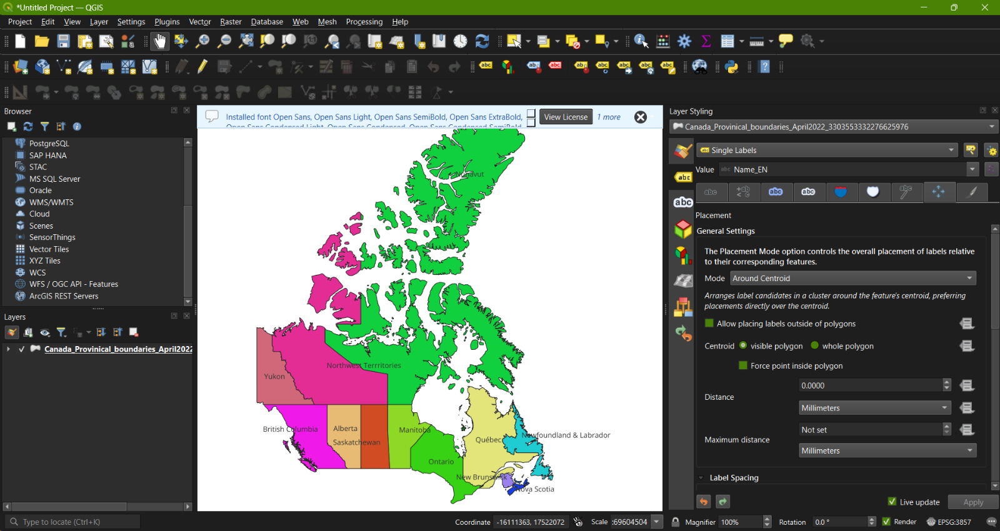

Our GeoJSON file was sourced from Geo.ca. Geo.ca is the Government of Canada's open geospatial data platform. It aggregates open licence geospatial data produced by FPT governments.

The Government of Manitoba produced a GeoJSON file of the provincial and territorial boundaries of Canada, as seen in this QGIS screenshot. Unfortunately, it was in a coordinate system unsupported by Plotly. Importing it into Plotly would cause the browser to freeze. Handling different data formats is a challenge that one may need to tackle as a data analyst. I used the open source mapping software QGIS to convert the GeoJSON file into the coordinate system used by Plotly.

### How are these average food price differences distributed geographically across Canada?

In [ ]:
import json
import re

# Import and clean GeoJSON
fp = open("sample_data/canada_provinces_qgis_export.geojson","r")
province_shapes = json.load(fp)
fp.close()
# Replace incorrect and encoding-corrupted labels
# This should've been done in QGIS earlier
for x in province_shapes["features"]:
    print(x["properties"]["Name_EN"])
    replacements = [("^Qu.+bec$","Quebec"),("^Newfoundland.+$","Newfoundland and Labrador"), ("^Northwest Terr.+$","Northwest Territories")]
    for replacement in replacements:
        pattern = re.compile(replacement[0])
        if pattern.match(x["properties"]["Name_EN"]):
            x["properties"]["Name_EN"] = replacement[1]
            print("\tCorrection: "+x["properties"]["Name_EN"])

Manitoba
Saskatchewan
Alberta
British Columbia
Nunavut
Northwest Terrritories
	Correction: Northwest Territories
Yukon
Ontario
Québec
	Correction: Quebec
New Brunswick
Nova Scotia
Newfoundland & Labrador
	Correction: Newfoundland and Labrador
Prince Edward Island
Canada


In [ ]:
# Outline-based maps have a similar constructor. If we were to use one, we would use the px.choropleth type
# When we use px.choropleth, we would have the additional args projection="mercator", fitbounds="locations"
fig = px.choropleth_map(latest_year_df, geojson=province_shapes,
                    locations='GEO',
                    featureidkey="properties.Name_EN",
                    color="VALUE",
                    labels={"GEO":geo_label, "VALUE":value_label_mean},
                    center={"lat":43,"lon":-79},
                    zoom=2
                    )
# In px.choropleth, we may want to change the colour of the base map as it does not have the colouring from map tiles
# fig.update_geos(showocean=True,oceancolor="Black",showlakes=True,lakecolor="Black",showland=True,landcolor="Grey")
fig.update_layout(map_style="dark")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

In [ ]:
fig = px.choropleth(latest_year_df, geojson=province_shapes,
                    locations='GEO',
                    featureidkey="properties.Name_EN",
                    color="VALUE",
                    labels={"GEO":geo_label, "VALUE":value_label_mean},
                    projection="mercator",
                    fitbounds="locations"
                    )
fig.update_geos(showocean=True,oceancolor="Black",showlakes=True,lakecolor="Black",showland=True,landcolor="Grey")
#fig.update_layout(map_style="dark")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

The map shows that **most provinces have similar average food prices**, while **Yukon stands out with a noticeably lower average**. Darker regions represent higher average food prices, while lighter regions represent lower prices.

Since Yukon appears lower on the map, is this part of a broader northern pattern?

### Are food prices lower overall in the North?

In [ ]:
value_label = "Food Price"
products_label = "Product"
fig = px.box(latest_year_allprods_df,
                x="GEO",
                y="VALUE",
                points="all",
                hover_data=["Products"],
                color="GEO",
                labels={"GEO":geo_label, "VALUE":value_label, "Products":products_label},
                title="Distribution of Food Prices by Province/Territory"
            )
fig.show()

In [ ]:
value_label = "Food Price"
products_label = "Product"
fig = px.scatter(latest_year_allprods_df,
                x="GEO",
                y="VALUE",
                hover_data=["Products"],
                color="Food_category",
                labels={"GEO":geo_label, "VALUE":value_label, "Products":products_label},
                title="Distribution of Food Prices by Province/Territory"
            )
fig.update_traces(marker={"size":10,"opacity":0.5})
fig.show()

Yukon and the Northwest Territories have medians around $4–$5, similar to several provinces. Across regions, most products fall below roughly $10–$12, while expensive products create outliers reaching about $50–$60.

### What are the most expensive products?

 Additonal Data Wrangling

In [ ]:
latest_year_allprods_max5_df = pd.DataFrame(columns = latest_year_allprods_df.columns)
# Aggregate by province/territory
for x in latest_year_allprods_df["GEO"].unique():
    tmp_geo_df = latest_year_allprods_df[latest_year_allprods_df["GEO"] == x]
    # Eliminate duplicate products
    tmp_max_df = pd.DataFrame(columns=tmp_geo_df.columns)
    for y in tmp_geo_df["Products"].unique():
        tmp_prod_df = tmp_geo_df[tmp_geo_df["Products"] == y].sort_values("VALUE",ascending=False).head(1)
        tmp_max_df = pd.concat([tmp_max_df,tmp_prod_df])
    latest_year_allprods_max5_df = pd.concat([latest_year_allprods_max5_df, tmp_max_df.sort_values("VALUE",ascending=False).head(5)])
latest_year_allprods_max5_df.head()

/tmp/ipykernel_1492/3220902962.py:9: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1492/3220902962.py:9: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

/tmp/ipykernel_1492/3220902962.py:10: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,GEO,year,Products,Food_category,VALUE
132828,Quebec,2026,"Beef rib cuts, per kilogram",Meat & Poultry,58.68
131603,Quebec,2026,"Infant formula, 900 grams",Infant Food,49.33
135442,Quebec,2026,"Beef striploin cuts, per kilogram",Meat & Poultry,40.87
135443,Quebec,2026,"Beef top sirloin cuts, per kilogram",Meat & Poultry,38.59
131531,Quebec,2026,"Salmon, per kilogram",Seafood,27.22


### Grouped vs Faceted Bars

In [ ]:
fig = px.bar(latest_year_allprods_max5_df,
             x="GEO", y="VALUE", color='Products',
             barmode='group',
             labels={"GEO":geo_label, "VALUE":value_label, "Products":products_label}
            )
fig.show()

In [ ]:
fig = px.bar(latest_year_allprods_max5_df,
             x="Products", y="VALUE", color='Products',
             facet_col='GEO',
             labels={"GEO":geo_label, "VALUE":value_label, "Products":products_label},
             facet_col_wrap = 3
            )
fig.update_layout(height=1200)
fig.show()

The product-level view shows a clear gap: the highest-priced products reach roughly $45–$55, while the next group is often around $25–$35. These expensive products appear across multiple provinces, showing that the highest prices are driven more by specific products than geography alone.

Where does this lead us:

* We found where prices differ.
* We identified what products drive the highest prices.
* Now we need to understand how those prices changed over time.

# **Business Question - Grocery Price Inflation**
## **Q. Which grocery products have experienced the largest price increases, and when did those increases occur?**



### Which products experienced the greatest overall price increase over time?

In [ ]:
# Convert columns
df["REF_DATE"] = pd.to_datetime(df["REF_DATE"], errors="coerce")
df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")

 # Remove missing values
df = df.dropna(subset=["Products", "REF_DATE", "VALUE"])

# Check available geographic values
print("\nGeographic values:")
print(df["GEO"].unique())

# Keep only Canada observations
canada = df[
    df["GEO"].astype(str).str.strip().str.lower() == "canada"
].copy()

print("\nCanada dataset shape:", canada.shape)

# Sort data
canada = canada.sort_values(
    ["Products", "REF_DATE"]
).copy()

#Calculate cumulative percentage change
# First price for each product
first_price = (
    canada
    .groupby("Products")["VALUE"]
    .transform("first")
)

# Cumulative percentage change
canada["Cumulative_Pct_Change"] = (
    (canada["VALUE"] - first_price)
    / first_price
) * 100


#  Create Price Index
canada["Price_Index"] = (
    canada["VALUE"] / first_price
) * 100


#  Get latest observation for each product
latest = (
    canada
    .sort_values("REF_DATE")
    .groupby("Products", as_index=False)
    .tail(1)
)

# Find top 10 products
top_products = (
    latest
    .dropna(subset=["Cumulative_Pct_Change"])
    .sort_values(
        "Cumulative_Pct_Change",
         ascending=False
    )
    .head(10)
)

# Display results
print("\nTop 10 Products by Overall Price Increase:")
print(
    top_products[
        [
            "Products",
            "REF_DATE",
            "VALUE",
            "Cumulative_Pct_Change"
        ]
    ].to_string(index=False)
)

# Get names of top 10 products
top_product_names = top_products["Products"].tolist()

# Filter data for top 10 products
q1 = canada[
    canada["Products"].isin(top_product_names)
].copy()


Geographic values:
['Alberta', 'British Columbia', 'Canada', 'Manitoba', 'New Brunswick', ..., 'Prince Edward Island', 'Quebec', 'Saskatchewan', 'Whitehorse, Yukon', 'Yellowknife, Northwest Territories']
Length: 13
Categories (13, object): ['Alberta', 'British Columbia', 'Canada', 'Manitoba', ..., 'Quebec',
                          'Saskatchewan', 'Whitehorse, Yukon',
                          'Yellowknife, Northwest Territories']

Canada dataset shape: (12650, 25)

Top 10 Products by Overall Price Increase:
                           Products   REF_DATE  VALUE  Cumulative_Pct_Change
                        Limes, unit 2026-07-01   0.95             126.190476
Beef top sirloin cuts, per kilogram 2026-07-01  28.22             109.970238
Roasted or ground coffee, 340 grams 2026-07-01   9.54             107.843137
    Beef stewing cuts, per kilogram 2026-07-01  26.31             107.819905
            Carrots, 1.36 kilograms 2026-07-01   4.75              93.089431
   Pork shoulder cuts,

/tmp/ipykernel_1492/1590716066.py:28: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/1590716066.py:49: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
# Plotly Line Chart
fig = px.line(
    q1,
    x="REF_DATE",
    y="VALUE",
    color="Products",
    markers=False,
    title="Top 10 Products by Overall Price Increase - Canada",
    labels={
        "REF_DATE": "Date",
        "VALUE": "Average Retail Price",
        "Products": "Product"
    },

    hover_data=[
        "Cumulative_Pct_Change",
        "Price_Index"
    ]
)

fig.update_layout(
    template="plotly_white",
    hovermode="closest",
    legend_title="Product",
    xaxis_title="Year",
    yaxis_title="Average Retail Price"
)
fig.show()

The chart shows a clear long-term upward trend among the top products. For example, beef stewing cuts reached $23.90 - Feb(2026), $88.8% cumulative increase, while infant formula rose from roughly $27 - $50.
So, the increase was substantial - but the line chart does not tell us whether this growth was gradual or caused by sudden yearly spikes.

### Which products experienced the largest year-over-year price spikes?

In [ ]:
canada["YoY_Pct_Change"] = (
    canada.groupby("Products")["VALUE"]
    .pct_change(12) * 100
)

# Find maximum YoY increase for every product
yoy_max = (
    canada
    .dropna(subset=["YoY_Pct_Change"])
    .groupby("Products", observed=True, as_index=False)
    .agg(
        Max_YoY_Increase=("YoY_Pct_Change", "max")
    )
    .sort_values("Max_YoY_Increase", ascending=False)
)

# Select top 10 products with the biggest hikes
top_10_products = yoy_max.head(10)["Products"].tolist()

q2 = canada[
    canada["Products"].isin(top_10_products)
].copy()

# Keep only positive YoY changes
q2 = q2[
    q2["YoY_Pct_Change"] > 0
]


/tmp/ipykernel_1492/3419952468.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:


# Plot Area Chart
fig = px.area(
    q2,
    x="REF_DATE",
    y="YoY_Pct_Change",
    color="Products",
    title="Products with the Biggest Year-over-Year Price Hikes",
    labels={
        "REF_DATE": "Date",
        "YoY_Pct_Change": "Year-over-Year Price Increase (%)",
        "Products": "Product"
    },
    hover_data=["VALUE", "YoY_Pct_Change"]
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    height=600
)
fig.show()

# Display the top 10
print("Products with the biggest YoY price hikes:")
display(yoy_max.head(10))

Products with the biggest YoY price hikes:


,Products,Max_YoY_Increase
28,"Celery, unit",110.569106
102,"Vegetable oil, 3 litres",105.818966
55,"Iceberg lettuce, unit",88.888889
82,"Pork shoulder cuts, per kilogram",71.327014
26,"Cantaloupe, unit",66.666667
7,"Beef rib cuts, per kilogram",63.907563
95,"Strawberries, 454 grams",62.903226
60,"Limes, unit",62.264151
25,"Canola oil, 3 litres",61.950549
100,"Tomatoes, per kilogram",53.761062


The spikes are much more dramatic than the long-term trend suggests. Celery recorded the largest YoY increase at 110.6%, followed by vegetable oil at 105.8% and iceberg lettuce at 88.9%.
This shows that some of the inflation was not gradual - certain products experienced very sharp short-term increases.

### How frequently did monthly price increases exceed major thresholds?

In [ ]:
canada["MoM_Pct_Change"] = (
    canada.groupby("Products")["VALUE"]
    .pct_change() * 100
)
positive_changes = (
    canada
    .dropna(subset=["MoM_Pct_Change"])
)

positive_changes = positive_changes[
    positive_changes["MoM_Pct_Change"] > 0
]

thresholds = [2, 5, 10, 20]

funnel_data = []

for threshold in thresholds:
    count = (
        positive_changes["MoM_Pct_Change"] >= threshold
    ).sum()

    funnel_data.append({
        "Threshold": f"{threshold}% or more",
        "Monthly_Increase_Observations": count
    })

funnel_df = pd.DataFrame(funnel_data)

/tmp/ipykernel_1492/2416048403.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
# Plot Funnel Chart
fig = px.funnel(
    funnel_df,
    y="Threshold",
    x="Monthly_Increase_Observations",
    title="Monthly Price Increases at Increasing Thresholds",
    labels={
        "Threshold": "Minimum Monthly Increase",
        "Monthly_Increase_Observations":
            "Number of Monthly Increase Observations"
    }
)

fig.update_layout(
    template="plotly_white"
)

fig.show()
display(funnel_df)

,Threshold,Monthly_Increase_Observations
0,2% or more,4193
1,5% or more,2175
2,10% or more,914
3,20% or more,267


The frequency drops sharply as the threshold rises: 4,193 observations increased by at least 2%, 2,175 by 5%+, 914 by 10%+, and only 267 by 20%+.
That means only about 6% of the 2%+ increase observations also reached 20%+, showing that extreme monthly jumps occurred, but were relatively uncommon.

# **Business Question - Price Volatility**

**Grocery Price Inflation** showed that large price increases occur, but an increase does not necessarily mean instability. A product may rise steadily, while another repeatedly moves up and down.

## **Which food products experience the greatest price instability, and where are those fluctuations most severe?**

### Which products are the most unstable?

In [ ]:
import plotly.express as px
canada["REF_DATE"] = pd.to_datetime(canada["REF_DATE"])

# Sort by product and date
canada = canada.sort_values(
    ["Products", "REF_DATE"]
)
# 2. Calculate Month-over-Month % Change
canada["MoM_Pct_Change"] = (
    canada.groupby("Products")["VALUE"]
    .pct_change() * 100
)

# Remove missing values
price_changes = canada.dropna(
    subset=["MoM_Pct_Change"]
).copy()

# 3. Calculate price instability for each product
product_volatility = (
    price_changes
    .groupby("Products")
    .agg(
        Price_Volatility=("MoM_Pct_Change", "std"),
        Average_MoM_Change=("MoM_Pct_Change", "mean"),
        Largest_Increase=("MoM_Pct_Change", "max"),
        Largest_Decrease=("MoM_Pct_Change", "min"),
        Number_of_Changes=("MoM_Pct_Change", "count")
    )
    .reset_index()
    .sort_values(
        "Price_Volatility",
        ascending=False
    )
)

# Top 10 most unstable products
top_50_unstable = product_volatility.head(50)

display(top_50_unstable)

/tmp/ipykernel_1492/4212616977.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/4212616977.py:22: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Products,Price_Volatility,Average_MoM_Change,Largest_Increase,Largest_Decrease,Number_of_Changes
82,"Pork shoulder cuts, per kilogram",21.843500,2.657208,88.186813,-33.974359,114
7,"Beef rib cuts, per kilogram",20.365759,2.414773,49.072848,-33.540649,114
95,"Strawberries, 454 grams",18.654120,1.764874,51.122195,-34.280639,114
26,"Cantaloupe, unit",16.797921,1.805662,34.532374,-34.899329,114
86,"Romaine lettuce, unit",15.063532,1.526287,52.036199,-33.453237,114
55,"Iceberg lettuce, unit",15.056048,1.478791,44.897959,-28.338762,114
9,"Beef striploin cuts, per kilogram",14.282802,1.467435,43.266769,-26.818769,114
52,"Grapes, per kilogram",14.114040,0.991403,55.521472,-34.728033,114
79,"Peppers, per kilogram",13.823726,1.145547,48.941176,-29.940828,114
28,"Celery, unit",13.397179,1.260281,39.354839,-37.960340,114


In [ ]:
#Plotly bar chart
fig = px.bar(
    top_50_unstable,
    x="Price_Volatility",
    y="Products",
    orientation="h",
    title="Food Products by Price Instability",
    color="Products",
    labels={
        "Price_Volatility": "Standard Deviation of Monthly Price Change (%)",
        "Products": "Food Product"
    }
)

fig.update_layout(
    template="plotly_white",
    yaxis={"categoryorder": "total ascending"},
    title_x=0.5
)

fig.show()

Beef rib cuts show about 20.4% volatility, placing them among the most unstable products. Several meats and fresh produce items also rank near the top, showing that instability is concentrated in particular products rather than evenly across food.

This leads to:A volatility score gives us the overall instability, but how extreme are the actual monthly price movements?

### How extreme are these monthly fluctuations?

In [ ]:
volatility_df = df.copy()
volatility_df["VALUE"] = pd.to_numeric(
    volatility_df["VALUE"],
    errors="coerce"
)

volatility_df["REF_DATE"] = pd.to_datetime(
    volatility_df["REF_DATE"],
    errors="coerce"
)

#Sort data
volatility_df = volatility_df.sort_values(
    ["Products", "GEO", "REF_DATE"]
).copy()

# Calculate month-over-month change
volatility_df["MoM_Pct_Change"] = (
    volatility_df
    .groupby(["Products", "GEO"])["VALUE"]
    .pct_change()
    * 100
)
df["Date"] = pd.to_datetime(df["REF_DATE"])
# Calculate month-over-month price change
df["MoM_Change"] = (
    df.groupby(["GEO", "Products"])["VALUE"]
      .diff()
)

# Calculate month-over-month percentage change
df["MoM_Pct_Change"] = (
    df.groupby(["GEO", "Products"])["VALUE"]
      .pct_change() * 100
)

# Date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Quarter"] = df["Date"].dt.quarter

df.head()

#Remove infinite and missing values
volatility_df["MoM_Pct_Change"] = (
    volatility_df["MoM_Pct_Change"]
    .replace([np.inf, -np.inf], np.nan)
)

volatility_df = volatility_df.dropna(
    subset=[
        "Products",
        "MoM_Pct_Change"
    ]
)

#Calculate Q1, Q3 and IQR
distribution_stats = (
    volatility_df
    .groupby("Products", as_index=False)
    .agg(
        Q1=(
            "MoM_Pct_Change",
            lambda x: x.quantile(0.25)
        ),

        Q3=(
            "MoM_Pct_Change",
            lambda x: x.quantile(0.75)
        )
    )
)

distribution_stats["IQR"] = (
    distribution_stats["Q3"]
    - distribution_stats["Q1"]
)

#Top 12 products
top_distribution = (
    distribution_stats
    .sort_values(
        "IQR",
        ascending=False
    )
    .head(12)
)

top_distribution_products = (
    top_distribution["Products"]
    .tolist()
)

print("Top 12 products with the widest distribution:")

display(
    top_distribution[
        [
            "Products",
            "Q1",
            "Q3",
            "IQR"
        ]
    ].style.format({
        "Q1": "{:.2f}%",
        "Q3": "{:.2f}%",
        "IQR": "{:.2f}%"
    })
)

#Filtering data for violin plot
q2 = volatility_df[
    volatility_df["Products"].isin(
        top_distribution_products
    )
].copy()

#Order the products by the value by IQR
product_order = (
    top_distribution
    .sort_values("IQR")
    ["Products"]
    .tolist()
)


/tmp/ipykernel_1492/3905591076.py:20: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/3905591076.py:27: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/3905591076.py:33: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Top 12 products with the widest distribution:


/tmp/ipykernel_1492/3905591076.py:61: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,Products,Q1,Q3,IQR
7,"Beef rib cuts, per kilogram",-12.13%,16.59%,28.72%
82,"Pork shoulder cuts, per kilogram",-11.15%,13.66%,24.81%
95,"Strawberries, 454 grams",-10.70%,12.36%,23.07%
9,"Beef striploin cuts, per kilogram",-9.48%,12.71%,22.19%
22,"Canned soup, 284 millilitres",-8.84%,12.25%,21.09%
10,"Beef top sirloin cuts, per kilogram",-8.74%,11.08%,19.82%
26,"Cantaloupe, unit",-8.29%,10.64%,18.93%
107,"Whole chicken, per kilogram",-8.64%,9.41%,18.06%
86,"Romaine lettuce, unit",-7.26%,9.59%,16.85%
97,"Sweet potatoes, per kilogram",-7.53%,8.89%,16.42%


In [ ]:
#Create violin plot
fig = px.violin(
    q2,
    x="MoM_Pct_Change",
    y="Products",
    orientation="h",
    box=True,
    points=False,
    color="Products",
color_discrete_sequence=px.colors.qualitative.Set2,
    category_orders={
        "Products": product_order
    },

    title=(
        "Distribution of Monthly Price Changes "
        "— Products with Highest IQR"
    ),

    labels={
        "MoM_Pct_Change":
            "Monthly Price Change (%)",

        "Products":
            "Food Product"
    }
)
fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=700,
    margin=dict(
        l=250,
        r=40,
        t=90,
        b=80
    )
)

fig.update_xaxes(
    zeroline=True,
    zerolinewidth=1
)

fig.show()

The violin plot reveals much larger extremes than the averages suggest. Beef striploin reaches roughly +140% monthly change and pork shoulder about +125%, while some observations fall below −50%.

We now know **What** is unstable and how extreme the fluctuations can be, but **Where** are they occurring?

### Where are price fluctuations most severe?

In [ ]:
geo_product_volatility = (
    df.groupby(["GEO", "Products"])
      .agg(
          Volatility=("MoM_Pct_Change", "std"),
          Average_Abs_MoM=("MoM_Pct_Change",
                           lambda x: np.nanmean(np.abs(x))),
          Minimum_MoM=("MoM_Pct_Change", "min"),
          Maximum_MoM=("MoM_Pct_Change", "max"),
          Observations=("MoM_Pct_Change", "count")
      )
      .reset_index()
)

# Require at least 12 monthly changes
gep_product_volatility = geo_product_volatility[
    geo_product_volatility["Observations"] >= 12
]

geo_product_volatility = geo_product_volatility.sort_values(
    "Volatility",
    ascending=False
)

geo_product_volatility.head(20)

/tmp/ipykernel_1492/882977657.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,GEO,Products,Volatility,Average_Abs_MoM,Minimum_MoM,Maximum_MoM,Observations
1260,"Whitehorse, Yukon","Frozen spinach, 300 grams",53.403164,25.398414,-62.383544,149.373064,10
852,Ontario,"Pork shoulder cuts, per kilogram",34.873178,24.258125,-55.462185,113.564669,114
999,Quebec,"Beef striploin cuts, per kilogram",32.569839,24.023386,-56.245408,132.913518,114
1072,Quebec,"Pork shoulder cuts, per kilogram",31.359975,24.075192,-50.106610,101.969365,114
887,Prince Edward Island,"Beef rib cuts, per kilogram",31.171501,24.447825,-48.274525,89.303483,114
1182,Saskatchewan,"Pork shoulder cuts, per kilogram",30.658689,21.785519,-57.162162,105.582524,114
997,Quebec,"Beef rib cuts, per kilogram",30.543433,23.945843,-51.083815,90.050668,114
1362,"Yellowknife, Northwest Territories","Flatbread and pita, 500 grams",30.487260,12.527555,-44.639932,80.635617,10
82,Alberta,"Pork shoulder cuts, per kilogram",29.034336,21.250274,-50.681199,88.988764,114
192,British Columbia,"Pork shoulder cuts, per kilogram",28.997091,20.965559,-51.014885,101.933702,114


In [ ]:
#Plotly Heatmap
#products with the highest overall volatility
top10 = product_volatility.head(10)["Products"].tolist()

heatmap_data = geo_product_volatility[
    geo_product_volatility["Products"].isin(top10)
].pivot(
    index="GEO",
    columns="Products",
    values="Volatility"
)

fig = px.imshow(
    heatmap_data,
    aspect="auto",
    text_auto=".1f",
    title="Where Are Price Fluctuations Most Severe?",
    labels={
        "x": "Product",
        "y": "Geography",
        "color": "Volatility (%)"
    }
)
fig.update_layout(
    height=650,
    xaxis_tickangle=-45
)

fig.show()

Volatility is clearly uneven across regions. The highest visible value is 34.9% in Ontario, while Quebec reaches 32.6% for another product and Prince Edward Island reaches 31.2%, showing that risk depends on the product – region combination, not geography alone.

# **Business Question - Food Basket Cost Drivers**

**Volatility** showed which products are unstable, how extreme their fluctuations are, and where that volatility is concentrated. But to answer the household-level question : We visualized on the products and categories that matters the most.

In [ ]:
latest_date = df["REF_DATE"].max()

df_pie = df[
    (df["GEO"] == "Canada") &
    (df["REF_DATE"] == latest_date) &
    (df["Food_category"] != "Non-Food")
].copy()

print("Products included:", df_pie["Products"].nunique())

#Dividing as per category
product_snapshot = (
    df_pie
    .groupby(
        ["Food_category", "Products"],
        as_index=False,
        observed=True
    )
    .agg(
        Product_price=("VALUE", "mean")
    )
)

#Sum the listed products category
category_cost = (
    product_snapshot
    .groupby("Food_category", as_index=False)
    .agg(
        Basket_cost=("Product_price", "sum"),
        Product_count=("Products", "nunique")
    )
)

#Calculate Percentage Share
category_cost["Share_percent"] = (
    category_cost["Basket_cost"]
    / category_cost["Basket_cost"].sum()
    * 100
)
category_cost = category_cost.sort_values(
    "Basket_cost",
    ascending=False
)
print(category_cost)

Products included: 106
              Food_category  Basket_cost  Product_count  Share_percent
5            Meat & Poultry       224.76             14      31.752041
10               Vegetables        98.37             24      13.896816
4               Infant Food        51.44              2       7.266974
2                    Fruits        49.10             12       6.936400
1              Dairy & Eggs        48.06              9       6.789478
7   Pantry & Packaged Foods        47.80             15       6.752748
9                   Seafood        42.52              4       6.006838
3           Grains & Bakery        38.31              8       5.412087
6            Oils & Spreads        38.25              4       5.403611
8     Plant Proteins & Nuts        36.03              8       5.089990
0                 Beverages        33.22              6       4.693018


### Which food categories contribute the largest share of the grocery basket cost?

In [ ]:
fig = px.pie(
    category_cost,
    names="Food_category",
    values="Basket_cost",
    title=(
        "Share of Constructed Food Basket Cost by Category"
        f"<br><sup>Canada - {latest_date.strftime('%B %Y')}</sup>"
    )
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Constructed Basket Cost: $%{value:.2f}<br>"
        "Share: %{percent}"
        "<extra></extra>"
    )
)

fig.update_layout(
    title_x=0.5,
    legend_title_text="Food category",
    margin=dict(
        l=40,
        r=40,
        t=100,
        b=40
    )
)
fig.show()

Meat & Poultry dominates the basket at 224.76(dollar), or about 31.8%, followed by Vegetables at $98.37, or 13.9%. No other category individually contributes even 8%. Meat & Poultry is clearly the largest category - but which individual products are creating that cost?

### Which individual products are driving the cost within each food category?

In [ ]:
#Tree map
latest_date = df["REF_DATE"].max()

tree_data = df[
     (df["GEO"] == "Canada") &
     (df["REF_DATE"] == latest_date) &
     (df["Food_category"] != "Non-Food")
 ].copy()

fig = px.treemap(
    tree_data,
    path=["Food_category", "Products"],
    values="VALUE",
    hover_data=["VALUE"],
    title="Food Cost Structure by Category and Product"
)

fig.update_layout(
    title_x=0.5
)
fig.show()

/usr/local/lib/python3.13/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



The treemap reveals the products behind the category totals. Beef striploin contributes 38.36(dollar) and beef rib cuts 33.75(dollar) within Meat & Poultry, while infant formula alone contributes 49.95(dollar) to Infant Food.

### How are products structured by food category and price level?

In [ ]:
#Sunburst
sun_data = tree_data.sort_values(
    "VALUE", ascending=False
).groupby("Food_category").head(5)

fig = px.sunburst(
    sun_data,
    path=["Food_category", "price_category", "Products"],
    values="VALUE",
    title="Food Price Structure by Category"
)

fig.update_traces(
    textinfo="label"
)
fig.show()

/usr/local/lib/python3.13/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.13/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



The hierarchy shows that 126.64(dollar) of Meat & Poultry falls into the Medium price level, while Infant Food is dominated by the High - price segment at 49.95(dollar), driven almost entirely by infant formula.

We have analyzed the Canada - level basket, But do these price structures appear similarly across provinces?

In [ ]:
group_map = {
     "Meat & Poultry": "Protein",
     "Seafood": "Protein",
     "Plant Proteins & Nuts": "Protein",
     "Fruits": "Produce",
     "Vegetables": "Produce",
     "Dairy & Eggs": "Dairy",
     "Grains & Bakery": "Pantry & Staples",
     "Pantry & Packaged Foods": "Pantry & Staples",
     "Oils & Spreads": "Pantry & Staples"
}

df["Category_group"] = df["Food_category"].map(group_map)

parallel_data = df[
    (df["REF_DATE"] == latest_date) &
    (df["GEO"] != "Canada") &
    (df["Category_group"].notna())
].head(100)

### How are food groups, price levels and provinces connected?

In [ ]:
#Parallel categories
fig = px.parallel_categories(
    parallel_data,
    dimensions=["Category_group", "price_category", "GEO"],
    labels={
        "Category_group": "Food Group",
        "price_category": "Price Level",
        "GEO": "Province / Territory"
    },
    title="Food Price Patterns across Canadian Provinces - first 100 Records"
)

fig.update_layout(
    title_x=0.5,
    height=650
)
fig.show()

The records show that Protein and Produce flow through multiple price levels and provinces, rather than following one fixed geographic pattern. This shows that basket structure depends on the combination of food group + price level + geography.

### How is the aggregated food-price value distributed from food groups across provinces?

In [ ]:
sankey_data = df[
    (df["REF_DATE"] == latest_date) &
    (df["GEO"] != "Canada") &
    (df["Category_group"].notna())
].head(100)

groups = sankey_data["Category_group"].unique().tolist()
provinces = sankey_data["GEO"].unique().tolist()

labels = groups + provinces
label_index = {name: i for i, name in enumerate(labels)}

source = sankey_data["Category_group"].map(label_index)
target = sankey_data["GEO"].map(label_index)

In [ ]:
#Sankey
fig = go.Figure(go.Sankey(
    node=dict(
        label=labels,
        pad=20,
        thickness=20
    ),
    link=dict(
        source=source,
        target=target,
        value=sankey_data["VALUE"]
    )
))
fig.update_layout(
    title=dict(
        text=(
            "Food Price Flow across Canadian Provinces"
            "<br><sup>Food Group → Province</sup>"
        ),
        x=0.5
    ),
    height=650,
    font=dict(size=12)
)
fig.show()

Protein produces the strongest flows in this record sample. The largest visible Protein flows include 49.96(Dollar) to Prince Edward Island, 48.22(Dollar) to Newfoundland  - and Labrador, and 43.24(Dollar) to Alberta - which are the connections that carry the greatest food - price value.

### How does the total grocery basket cost change month by month, and which categories contribute to that change?

In [ ]:
year_selected = 2025

bar_data = df[
    (df["GEO"] == "Canada") &
    (df["year"] == year_selected) &
    (df["Food_category"] != "Non-Food")
].copy()

bar_data["Month"] = bar_data["REF_DATE"].dt.strftime("%b")

bar_data = bar_data.groupby(
    ["month", "Month", "Food_category"],
    as_index=False
)["VALUE"].sum()

bar_data = bar_data.sort_values("month")

In [ ]:
#Bar chart
fig = px.bar(
    bar_data,
    x="Month",
    y="VALUE",
    color="Food_category",
    barmode="stack",
    labels={
        "Month": "Month",
        "VALUE": "Constructed Basket Cost ($)",
        "Food_category": "Food Category"
    },
    title=(
        f"Monthly Grocery Basket Cost by Food Category - {year_selected}"
        "<br><sup>Canada | Category contribution to the constructed basket total</sup>"
    )
)

fig.update_layout(
    title_x=0.5,
    yaxis_tickprefix="$",
    legend_title_text="Food Category",
    hovermode="x unified",
    height=650
)
fig.show()

The constructed basket rises from 651.97(Dollar) in January to a peak of 698.95(Dollar) in November, an increase of about $47. Meat & Poultry remains the largest contributor throughout the year. This chart shows whether the basket cost stayed stable throughout the year.

### How have these provincial price patterns changed over time?

In [ ]:
df_bar = df.copy()

#Remove national canada total
df_bar = df_bar[df_bar["GEO"] != "Canada"].copy()

#Average Price Calculation
bar_data = (
    df_bar.groupby(
        ["year", "GEO", "price_category"],
        as_index=False,
        observed=True
    )
    .agg(Average_price=("VALUE", "mean"),
        Product_count=("Products", "nunique")
    )
)

#Create every year x geography x Price category combination

years = sorted(df_bar["year"].unique())
geographies = sorted(df_bar["GEO"].unique())
categories = ["Low", "Medium", "High"]

full_index = pd.MultiIndex.from_product(
    [years, geographies, categories],
    names=["year", "GEO", "price_category"]
)

bar_data = (
    bar_data
    .set_index(["year", "GEO", "price_category"])
    .reindex(full_index)
    .reset_index()
)

bar_data["Average_price"] = bar_data["Average_price"].fillna(0)
bar_data["Product_count"] = bar_data["Product_count"].fillna(0)

print(
    bar_data.groupby("price_category")["Average_price"]
    .agg(["count", "min", "max", "mean"])
)

#Solving high category issue
print(
    bar_data[
        (bar_data["price_category"] == "High") &
        (bar_data["Average_price"] > 0)
    ][
        ["year", "GEO", "Average_price", "Product_count"]
    ].head(20)
)

                count  min        max       mean
price_category                                  
High              120  0.0  51.750000  16.667768
Low               120  0.0   5.572262   4.157804
Medium            120  0.0  31.165556  21.806686
     year                        GEO  Average_price  Product_count
218  2023                    Alberta      41.125000            1.0
221  2023           British Columbia      40.570000            1.0
224  2023                   Manitoba      41.636667            1.0
227  2023              New Brunswick      40.413333            2.0
230  2023  Newfoundland and Labrador      42.107273            2.0
233  2023                Nova Scotia      41.405000            2.0
236  2023                    Ontario      40.810000            1.0
239  2023       Prince Edward Island      40.876250            2.0
242  2023                     Quebec      41.142500            2.0
245  2023               Saskatchewan      40.636667            1.0
254  2024         

In [ ]:
#Bar chart
fig = px.bar(
    bar_data,
    x="GEO",
    y="Average_price",
    color="price_category",
    animation_frame="year",
    barmode="group",
    category_orders={
        "price_category": ["Low", "Medium", "High"]
    },

    labels={
        "GEO": "Province / Territory",
        "Average_price": "Average Retail Price ($)",
        "price_category": "Price Bracket",
        "year": "Year"
    },

   title=(
        "Grocery Price Brackets across Canadian Provinces"
        "<br><sup>Average Retail Price by Price Category and Year</sup>"
    ),

    hover_data={
        "Product_count": True,
        "Average_price": ":.2f"
    }
)

fig.update_layout(
    title_x=0.5,
    height=700,
    barmode="group",
    legend_title_text="Price Bracket",
    margin=dict(
        l=70,
        r=40,
        t=110,
        b=150
    )
)

fig.update_xaxes(
    tickangle=-45
)

fig.update_yaxes(
    tickprefix="$",
    range=[0, 60]
)

fig.update_traces(
    hovertemplate=
        "<b>%{x}</b><br>"
        "Average Price: $%{y:.2f}<br>"
        "<extra></extra>"
)

fig.show()

The animation shows that Low and Medium - price brackets evolve differently across provinces over time, with Medium-priced products consistently sitting well above the Low-price group. The interactive year control lets us see that the geographic pattern itself changes rather than remaining fixed.

### Which food categories contributed most to the overall increase in average prices?

In [ ]:
temp = df[
    (df["GEO"] == "Canada") &
    (df["Food_category"] != "Non-Food")
].copy()

# Average price by year and category
category_change = (
    temp.groupby(["year", "Food_category"], observed=True)["VALUE"]
        .mean()
        .unstack()
)
change = category_change.iloc[-1] - category_change.iloc[0]

# Sort largest increase first
change = change.sort_values(ascending=False)

In [ ]:
# Waterfall chart
fig = go.Figure(go.Waterfall(
    x=change.index,
    y=change.values,
    measure=["relative"] * len(change)
))

fig.update_layout(
    title="Which Food Categories drove increase in Prices?",
    xaxis_title="Food category",
    yaxis_title="Change in Average Price ($)",
    title_x=0.5,
    height=600
)
fig.show()

Infant Food is the largest driver, adding about 11.46(Dollar) to average price, followed by Meat & Poultry at 5.76(Dollar) and Oils & Spreads at 3.32(Dollar). All remaining categories contribute less than about $2 each.

# **Business Question - Pricing Anomalies & Emerging Risks**

**Food Basket Cost Drivers** included which categories and products contribute most and how those costs change over time.But a large price or large increase is not necessarily unusual. We still cannot tell which price movements are behaving abnormally compared with their own history.

## **Which product, geography, and time combinations show unusual price behaviour that may require attention?**

Rather than defining unusual behaviour using a single metric, we examine three complementary signals:
* Year-over-Year Change:How much has the price changed compared with the previous year?
* Price Volatility: How unstable have recent price movements been?
* Historical Deviation: How unusual is the observed price relative to its historical behaviour?

In [ ]:
df = df.sort_values(
    ["Products", "GEO", "REF_DATE"]
).copy()

# Year-over-year price change
df["YoY_change"] = (
    df.groupby(["Products", "GEO"])["VALUE"]
      .pct_change(12) * 100
)

# Monthly price change
df["Monthly_change"] = (
    df.groupby(["Products", "GEO"])["VALUE"]
      .pct_change() * 100
)

# 12-month price volatility
df["Volatility"] = (
    df.groupby(["Products", "GEO"])["Monthly_change"]
      .transform(lambda x: x.rolling(12).std())
)

# Historical deviation
group = df.groupby(["Products", "GEO"])["VALUE"]
df["Z_score"] = (
    (df["VALUE"]-group.transform("mean"))
    / group.transform("std")
)

# Keep complete observations
plot_3d = df.dropna(
    subset=["YoY_change", "Volatility", "Z_score"]
).copy()

# One point represents one product
product_3d = (
    plot_3d
    .groupby("Products", as_index=False)
    .agg(
        YoY_change=("YoY_change", "mean"),
        Volatility=("Volatility", "mean"),
        Z_score=("Z_score", lambda x: x.abs().mean())
    )
)
product_3d.head()

/tmp/ipykernel_1492/2796230430.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/2796230430.py:13: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/2796230430.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/2796230430.py:24: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=Fa

,Products,YoY_change,Volatility,Z_score
0,"Almonds, 200 grams",2.317410,5.216026,0.756416
1,"Apple juice, 2 litres",4.694599,5.071941,0.872807
2,"Apples, per kilogram",4.454051,9.346454,0.773637
3,"Avocado, unit",3.518448,9.374405,0.803869
4,"Baby food, 128 millilitres",2.278974,2.732873,0.839122


### Which Products show the Highest Price Risk?

In [ ]:
#Scatter 3d
fig = px.scatter_3d(
    product_3d,
    x="YoY_change",
    y="Volatility",
    z="Z_score",
    hover_name="Products",
    labels={
        "YoY_change": "Average YoY Change (%)",
        "Volatility": "Price Volatility (%)",
        "Z_score": "Historical Deviation"
    },
    title="Which Products show the Highest Price Risk?"
)

fig.update_traces(
    marker=dict(
        size=6,
        opacity=0.75
    )
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white",
    margin=dict(l=0, r=0, b=0, t=60)
)
fig.show()

The products do not occupy the same risk position. For example, cantaloupe shows about 5.67% average YoY growth, 15.44% volatility, and 0.80 historical deviation, combining growth and instability in one product.

### Where is Normal Price Behaviour concentrated?

In [ ]:
#density contour
fig = px.density_contour(
    product_3d,
    x="YoY_change",
    y="Volatility",
    labels={
        "YoY_change": "Average YoY Change (%)",
        "Volatility": "Price Volatility (%)"
    },
    title="Where is Normal Price Behaviour concentrated?"
)

fig.update_traces(
    contours_coloring="fill"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)
fig.show()

The highest-density region is concentrated around approximately 5% YoY change and 7.5% volatility, with 21 observations in the highlighted area. Observations farther away from this dense centre represent less common combinations of growth and volatility.

In [ ]:
# Find 15 products with the strongest historical deviation
top_products = (
    plot_3d
    .groupby("Products")["Z_score"]
    .apply(lambda x: x.abs().mean())
    .nlargest(15)
    .index
)
heatmap_data = plot_3d[
    plot_3d["Products"].isin(top_products)
].copy()

anomaly_matrix = heatmap_data.pivot_table(
    index="Products",
    columns="GEO",
    values="Z_score",
    aggfunc=lambda x: x.abs().mean()
)

/tmp/ipykernel_1492/658251956.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1492/658251956.py:13: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



### Which product - region combinations show the greatest historical deviation?

In [ ]:
#imshow/heatmap
fig = px.imshow(
    anomaly_matrix,
    labels={
        "x": "Region",
        "y": "Product",
        "color": "Historical deviation"
    },

    title="Where are Price Anomalies concentrated?",
    aspect="auto"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white",
    height=650
)
fig.show()

The heatmap pinpoints specific product – region combinations rather than treating the whole country equally. For example, salad dressing in Canada shows a historical deviation of about 0.922, while the displayed values across the heatmap range roughly from 0.82 to 0.94. This observation also tells us which product and regions are responsible for the normal behavior.

### How does a product's price-risk profile evolve over time?

In [ ]:
line_data = (
    plot_3d
    .groupby(["Products", "REF_DATE"], as_index=False)
    .agg(
        YoY_Change=("YoY_change", "mean"),
        Volatility=("Volatility", "mean"),
        Z_Score=("Z_score", lambda x: x.abs().mean())
    )
    .sort_values("REF_DATE")
)

# Product list
products = sorted(line_data["Products"].unique())
fig = go.Figure()

# Add one 3D line for each product
for product in products:
    data = line_data[line_data["Products"] == product]
    fig.add_trace(
        go.Scatter3d(
            x=data["YoY_Change"],
            y=data["Volatility"],
            z=data["Z_Score"],
            mode="lines",
            name=product,
            text=data["REF_DATE"].dt.strftime("%b %Y"),
            hovertemplate=
                "<b>%{text}</b><br>"
                "YoY change: %{x:.1f}%<br>"
                "Volatility: %{y:.1f}%<br>"
                "Deviation: %{z:.2f}"
                "<extra></extra>",

            visible=False
        )
    )

# Show first product initially
fig.data[0].visible = True

# Product dropdown
buttons = []

for i, product in enumerate(products):
    visible = [False] * len(products)
    visible[i] = True
    buttons.append(
        dict(
            label=product,
            method="update",
            args=[
                {"visible": visible},
                {"title": f"Price Risk Evolution: {product}"}
            ]
        )
    )

fig.update_layout(
    title=dict(
        text=f"Price Risk Evolution - {products[0]}",
        x=0.5,
        xanchor="center"
    ),

    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0.02,
            y=1.08,
            xanchor="left",
            yanchor="top"
        )
    ],
    scene=dict(
        # Make 3D chart use more of the available space
        domain=dict(
            x=[0.05, 0.95],
            y=[0.05, 0.90]
        ),

        xaxis=dict(
            title="YoY change (%)",
            titlefont=dict(size=13),
            tickfont=dict(size=11)
        ),

        yaxis=dict(
            title="Volatility (%)",
            titlefont=dict(size=13),
            tickfont=dict(size=11)
        ),

        zaxis=dict(
            title="Historical deviation",
            titlefont=dict(size=13),
            tickfont=dict(size=11)
        ),

        # Better viewing angle
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.1)
        ),

        aspectmode="cube"
    ),
    template="plotly_white",
    height=700,
    margin=dict(
        l=20,
        r=20,
        b=20,
        t=110
    )
)
fig.show()

/tmp/ipykernel_1492/2606619570.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



The 3D line shows how that position moves through time. The dropdown lets us follow products such as Almonds, Apple Juice, Apples, or Avocado individually, revealing periods when their growth, volatility, and deviation strengthen or weaken together. The plot shows whether risk was always present or developed over time.

### What is the latest overall risk level that requires monitoring?

In [ ]:
# Get latest observation for each product
latest_products = (
    plot_3d
    .sort_values("REF_DATE")
    .groupby("Products", as_index=False)
    .tail(1)
    .copy()
)

# Calculate anomaly strength
latest_products["Risk_score"] = latest_products["Z_score"].abs()

# Sort product names
latest_products = latest_products.sort_values("Products").reset_index(drop=True)

# Data-driven gauge maximum
gauge_max = max(4, latest_products["Risk_score"].max())

# Default product
first_product = latest_products.iloc[0]


/tmp/ipykernel_1492/1782267581.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
fig = go.Figure(
    go.Indicator(
        mode="number+gauge",
        value=first_product["Risk_score"],
        title={
            "text":
            f"Current Anomaly Signal<br>"
            f"<span style='font-size:0.8em'>{first_product['Products']}</span>"
        },
        number={
            "valueformat": ".2f"
        },
        gauge={
            "axis": {
                "range": [0, gauge_max]
            }
        }
    )
)

# Product dropdown
buttons = []

for _, row in latest_products.iterrows():
    buttons.append(
        dict(
            label=row["Products"],
            method="update",
            args=[
                {
                    "value": [row["Risk_score"]],
                    "title": [{
                        "text":
                        f"Current Anomaly Signal<br>"
                        f"<span style='font-size:0.8em'>{row['Products']}</span>"
                    }]
                }
            ]
        )
    )

fig.update_layout(

    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0,
            y=1.15,
            xanchor="left",
            yanchor="top"
        )
    ],
    template="plotly_white",
    height=450,
    margin=dict(
        l=50,
        r=50,
        t=120,
        b=40
    )
)
fig.show()

The indicator gauge provides a quick monitoring view of the selected product’s latest risk score. The gauge position shows where that product currently falls on the risk scale, making it easier to identify products that may require closer attention.

## Key Findings

- **Geographic Price Disparity:** Average food prices across most regions were around **$6–$7**, while Yukon was lower at approximately **5**. The highest-priced individual products reached roughly **45–55**, showing that product choice can create substantial price differences.

- **Grocery Price Inflation:** Beef stewing cuts reached **$23.90 by February 2026**, representing an **88.8% cumulative increase**. Short-term increases were even more extreme: **celery reached 110.6% YoY growth**, vegetable oil **105.8%**, and iceberg lettuce **88.9%**.

- **Price Volatility:** Beef rib cuts showed approximately **20.4% volatility**, while individual monthly movements were much more extreme - **beef striploin reached roughly +140%** and pork shoulder approximately **+125%**. Regional volatility also reached **34.9% in Ontario** and **32.6% in Quebec**.

- **Food Basket Cost Drivers:** **Meat & Poultry accounted for 224.76, or 31.8%, of the constructed basket**, making it the largest category. The basket increased from **651.97 in January to 698.95 in November 2025**, while Infant Food (**+11.46(dollar)**), Meat & Poultry (**+5.76(dollar)**), and Oils & Spreads (**+3.32(dollar)**) were major contributors to the overall increase.

- **Pricing Anomalies & Emerging Risks:** Normal price behaviour was concentrated around approximately **5% YoY change and 7.5% volatility**. Historical deviation in the anomaly heatmap reached roughly **0.94**, demonstrating how combining growth, volatility, and historical deviation can identify product–region combinations that stand apart from typical behaviour.

## Recommendations

- **Prioritize high-impact categories:** Closely monitor **Meat & Poultry**, which represents **31.8% of the constructed basket**, along with categories showing strong price increases such as Infant Food.

- **Separate inflation from volatility:** A product with a high price increase is not necessarily unstable. Track **price growth and volatility together** to distinguish sustained inflation from sudden fluctuations.

- **Monitor at the product-region level:** Volatility reached approximately **34.9% in Ontario** in the analyzed combinations, showing that national averages can hide localized price risks.

- **Use anomaly signals for early monitoring:** Combine **YoY change, volatility, and historical deviation** to flag unusual product-region behaviour for further investigation rather than relying on price alone.

## Conclusion & Future Scope

This analysis demonstrates that Canadian grocery prices are influenced by a combination of **geography, inflation, volatility, product/category contribution, and unusual price behaviour**.

The analysis could be extended by integrating external factors such as **inflation, fuel and transportation costs**, developing a fully interactive **Plotly Dash dashboard**, and automatically updating the anomaly-monitoring system as new monthly price data becomes available.